<a href="https://colab.research.google.com/github/IvanMalkS/IS/blob/master/CUSTOMER_CHURN_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [352]:
import kagglehub
blastchar_telco_customer_churn_path = kagglehub.dataset_download('blastchar/telco-customer-churn')
print('Импорт источника данных завершен.')

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Импорт источника данных завершен.


<a id = "1" ></a>
# <span style="font-family:serif; font-size:28px;"> Введение</span>
<a id = "introduction" ></a>

<span style="font-size:16px;"><b>Для снижения оттока клиентов телекоммуникационным компаниям необходимо прогнозировать, какие клиенты находятся в зоне высокого риска оттока.</b></span>

<span style="font-size:16px;"> Чтобы обнаружить ранние признаки потенциального оттока, необходимо сначала получить целостное представление о клиентах и их взаимодействиях по многочисленным каналам, включая посещения магазинов/филиалов, истории покупок продуктов, звонки в службу поддержки, транзакции через Интернет и взаимодействия в социальных сетях, и это лишь некоторые из них. </span>

<span style="font-size:16px;">В результате, борясь с оттоком, эти компании могут не только сохранить свои рыночные позиции, но и расти и процветать. Чем больше клиентов у них в сети, тем ниже затраты на инициацию и тем больше прибыль. Таким образом, основным направлением деятельности компании для достижения успеха является сокращение оттока клиентов и внедрение эффективной стратегии удержания. </span>
<a id="reduce"></a>

<a id = "4" ></a>
#### <b> Цели</b>
Я изучу данные и попытаюсь ответить на некоторые вопросы, такие как:
* Каков процент оттока клиентов и клиентов, которые остаются с активными услугами?
* Есть ли какие-либо закономерности в оттоке клиентов в зависимости от пола?
* Есть ли какие-либо закономерности/предпочтения в оттоке клиентов в зависимости от типа предоставляемой услуги?
* Какие типы услуг наиболее прибыльны?
* Какие функции и услуги наиболее прибыльны?
* Многие другие вопросы, которые возникнут в ходе анализа
<a id="objective"></a>

<a id = "5" ></a>
# <span style="font-family:serif; font-size:28px;"> Загрузка библиотек и данных</span>
<a id="loading"></a>

In [353]:
!pip install catboost
!pip install missingno
!pip install xgboost

import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

In [354]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn import metrics
from sklearn.metrics import roc_curve
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report

In [355]:
import os
df = pd.read_csv(os.path.join(blastchar_telco_customer_churn_path, 'WA_Fn-UseC_-Telco-Customer-Churn.csv'))

___

<a id = "6" ></a>
# <span style="font-family:serif; font-size:28px;"> Понимание данных</span>
<a id = "Undertanding the data" ></a>

Каждая строка представляет клиента, каждый столбец содержит атрибуты клиента, описанные в метаданных столбца.

In [356]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Набор данных включает информацию о:**
* **Клиентах, которые ушли в течение последнего месяца** – столбец называется Churn

* **Услугах, на которые подписался каждый клиент** – телефон, несколько линий, интернет, онлайн-безопасность, онлайн-резервное копирование, защита устройств, техническая поддержка, а также потоковое ТВ и фильмы

* **Информации об аккаунте клиента** - как долго они являются клиентами, контракт, способ оплаты, безбумажный счет, ежемесячные платежи и общая сумма платежей

* **Демографической информации о клиентах** – пол, возрастная группа, а также наличие партнеров и иждивенцев

In [357]:
df.shape

(7043, 21)

In [358]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [359]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

In [360]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object



* Целью, которую мы будем использовать для руководства исследованием, является **Отток**

***

<a id = "7" ></a>
# <span style="font-family:serif; font-size:28px;"> Визуализация пропущенных значений </span>
<a id = "missingvalue" ></a>

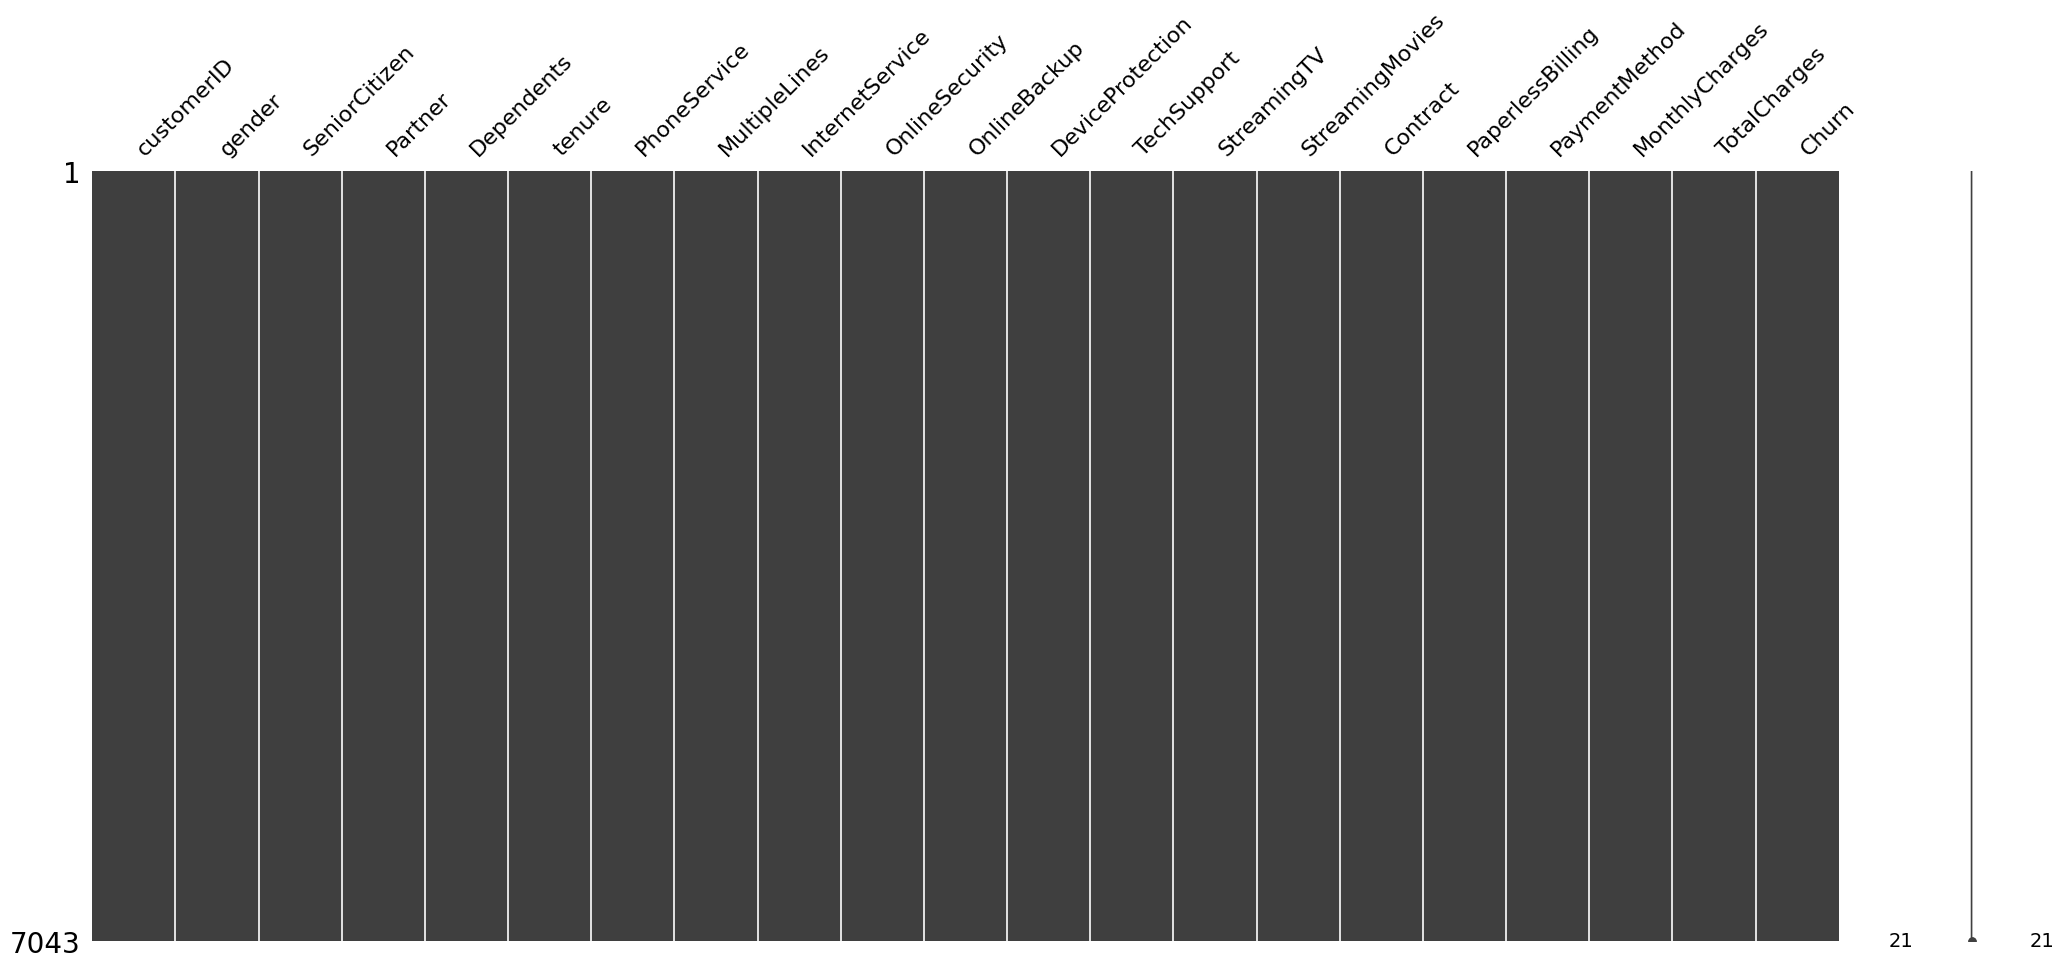

In [361]:
msno.matrix(df);

> Используя эту матрицу, мы можем очень быстро найти характер пропусков в наборе данных.
* Из приведенной выше визуализации мы можем заметить, что она не имеет особой закономерности, которая бы выделялась. Фактически, отсутствующих данных нет.

***

<a id = "8" ></a>
# <span style="font-family:serif; font-size:28px;"> Манипуляции с данными </span>
<a id = "8" ></a>

In [362]:
df = df.drop(['customerID'], axis = 1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


* При глубоком анализе мы можем обнаружить некоторые косвенные пропущенные значения в наших данных (которые могут быть в виде пробелов). Давайте посмотрим на это!

In [363]:
df['TotalCharges'] = pd.to_numeric(df.TotalCharges, errors='coerce')
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


* Здесь мы видим, что в TotalCharges 11 пропущенных значений. Давайте проверим эти данные.

In [364]:
df[np.isnan(df['TotalCharges'])]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


* Также можно отметить, что столбец Tenure равен 0 для этих записей, хотя столбец MonthlyCharges не пуст.

Давайте посмотрим, есть ли другие нулевые значения в столбце tenure.

In [365]:
df[df['tenure'] == 0].index

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

* В столбце Tenure нет дополнительных пропущенных значений.

Давайте удалим строки с пропущенными значениями в столбцах Tenure, так как их всего 11, и их удаление не повлияет на данные.

In [366]:
df.drop(labels=df[df['tenure'] == 0].index, axis=0, inplace=True)
df[df['tenure'] == 0].index

Index([], dtype='int64')

> Чтобы решить проблему пропущенных значений в столбце TotalCharges, я решил заполнить их средним значением TotalCharges.

In [367]:
df = df.fillna(df["TotalCharges"].mean())

In [368]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [369]:
df["SeniorCitizen"]= df["SeniorCitizen"].map({0: "No", 1: "Yes"})
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [370]:
df["InternetService"].describe(include=['object', 'bool'])

,InternetService
count,7032
unique,3
top,Fiber optic
freq,3096


In [371]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[numerical_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


<a id = "9" ></a>
# <span style="font-family:serif; font-size:28px;"> Визуализация данных </span>
<a id = "datavisualization" ></a>

In [372]:
g_labels = ['Male', 'Female']
c_labels = ['No', 'Yes']
fig = make_subplots(rows=1, cols=2, specs=[[{'type':'domain'}, {'type':'domain'}]])
fig.add_trace(go.Pie(labels=g_labels, values=df['gender'].value_counts(), name="Gender"), 1, 1)
fig.add_trace(go.Pie(labels=c_labels, values=df['Churn'].value_counts(), name="Churn"), 1, 2)
fig.update_traces(hole=.4, hoverinfo="label+percent+name", textfont_size=16)
fig.update_layout(title_text="Gender and Churn Distributions", annotations=[dict(text='Gender', x=0.16, y=0.5, font_size=20, showarrow=False), dict(text='Churn', x=0.84, y=0.5, font_size=20, showarrow=False)])
fig.show()

* 26,6% клиентов перешли в другую фирму.
* Среди клиентов 49,5% женщин и 50,5% мужчин.

In [373]:
df["Churn"][df["Churn"]=="No"].groupby(by=df["gender"]).count()

,Churn
gender,
Female,2544
Male,2619


In [374]:
df["Churn"][df["Churn"]=="Yes"].groupby(by=df["gender"]).count()

,Churn
gender,
Female,939
Male,930


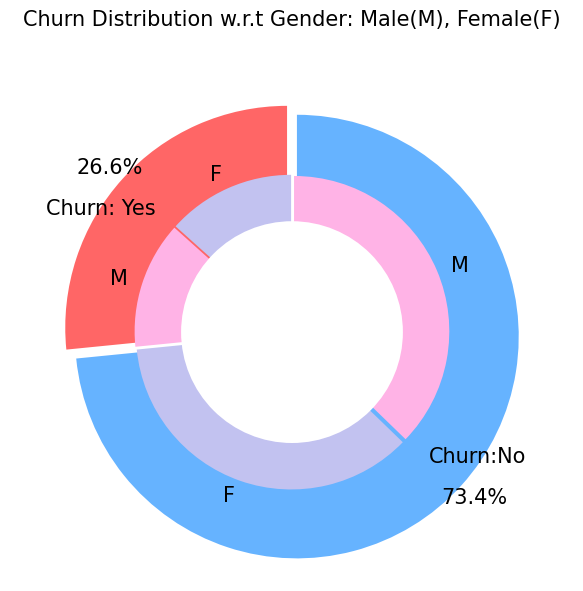

In [375]:
plt.figure(figsize=(6, 6))
labels =["Churn: Yes","Churn:No"]
values = [1869,5163]
labels_gender = ["F","M","F","M"]
sizes_gender = [939,930 , 2544,2619]
colors = ['#ff6666', '#66b3ff']
colors_gender = ['#c2c2f0','#ffb3e6', '#c2c2f0','#ffb3e6']
explode = (0.3,0.3)
explode_gender = (0.1,0.1,0.1,0.1)
textprops = {"fontsize":15}

plt.pie(values, labels=labels,autopct='%1.1f%%',pctdistance=1.08, labeldistance=0.8,colors=colors, startangle=90,frame=True, explode=explode,radius=10, textprops =textprops, counterclock = True, )
plt.pie(sizes_gender,labels=labels_gender,colors=colors_gender,startangle=90, explode=explode_gender,radius=7, textprops =textprops, counterclock = True, )

centre_circle = plt.Circle((0,0),5,color='black', fc='white',linewidth=0)
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Churn Distribution w.r.t Gender: Male(M), Female(F)', fontsize=15, y=1.1)


plt.axis('equal')
plt.tight_layout()
plt.show()

* Разница в проценте/количестве клиентов, сменивших поставщика услуг, незначительна. Оба пола вели себя одинаково, когда речь шла о переходе к другому поставщику услуг/фирме.

In [376]:
fig = px.histogram(df, x="Churn", color="Contract", barmode="group", title="<b>Распределение контрактов клиентов</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

* Около 75% клиентов с месячным контрактом решили уйти, по сравнению с 13% клиентов с годовым контрактом и 3% с двухлетним контрактом.

In [377]:
labels = df['PaymentMethod'].unique()
values = df['PaymentMethod'].value_counts()

fig = go.Figure(data=[go.Pie(labels=labels, values=values, hole=.3)])
fig.update_layout(title_text="<b>Распределение методов оплаты</b>")
fig.show()

In [378]:
fig = px.histogram(df, x="Churn", color="PaymentMethod", title="<b>Распределение методов оплаты клиентов по оттоку</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

* Большинство клиентов, которые ушли, использовали электронный чек в качестве способа оплаты.
* Клиенты, выбравшие автоматический перевод по кредитной карте или автоматический банковский перевод, а также оплату по почте в качестве способа оплаты, с меньшей вероятностью уходили.

In [379]:
df["InternetService"].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [380]:
 df[df["gender"]=="Male"][["InternetService", "Churn"]].value_counts()

,,count
InternetService,Churn,
DSL,No,992
Fiber optic,No,910
No,No,717
Fiber optic,Yes,633
DSL,Yes,240
No,Yes,57


In [381]:
df[df["gender"]=="Female"][["InternetService", "Churn"]].value_counts()

,,count
InternetService,Churn,
DSL,No,965
Fiber optic,No,889
No,No,690
Fiber optic,Yes,664
DSL,Yes,219
No,Yes,56


In [382]:
fig = go.Figure()

fig.add_trace(go.Bar(
  x = [['Отток: Нет', 'Отток: Нет', 'Отток: Да', 'Отток: Да'],
       ["Женщины", "Мужчины", "Женщины", "Мужчины"]],
  y = [965, 992, 219, 240],
  name = 'DSL',
))

fig.add_trace(go.Bar(
  x = [['Отток: Нет', 'Отток: Нет', 'Отток: Да', 'Отток: Да'],
       ["Женщины", "Мужчины", "Женщины", "Мужчины"]],
  y = [889, 910, 664, 633],
  name = 'Оптоволокно',
))

fig.add_trace(go.Bar(
  x = [['Отток: Нет', 'Отток: Нет', 'Отток: Да', 'Отток: Да'],
       ["Женщины", "Мужчины", "Женщины", "Мужчины"]],
  y = [690, 717, 56, 57],
  name = 'Нет Интернета',
))

fig.update_layout(title_text="<b>Распределение оттока по интернет-услугам и полу</b>")

fig.show()

* Многие клиенты выбирают услугу оптоволоконного интернета, и также очевидно, что клиенты, использующие оптоволоконный интернет, имеют высокий уровень оттока, что может указывать на недовольство этим типом интернет-услуг.
* Клиенты, пользующиеся услугой DSL, составляют большинство и имеют меньший уровень оттока по сравнению с оптоволоконной услугой.

In [383]:
color_map = {"Yes": "#FF97FF", "No": "#AB63FA"}
fig = px.histogram(df, x="Churn", color="Dependents", barmode="group", title="<b>Распределение иждивенцев</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

* Клиенты без иждивенцев чаще уходят

In [384]:
color_map = {"Yes": '#FFA15A', "No": '#00CC96'}
fig = px.histogram(df, x="Churn", color="Partner", barmode="group", title="<b>Распределение оттока по партнерам</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

* Клиенты, у которых нет партнеров, чаще уходят

In [385]:
color_map = {"Yes": '#00CC96', "No": '#B6E880'}
fig = px.histogram(df, x="Churn", color="SeniorCitizen", title="<b>Распределение оттока по пожилым гражданам</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

* Можно заметить, что доля пожилых граждан очень мала.
* Большинство пожилых граждан уходят.

In [386]:
color_map = {"Yes": "#FF97FF", "No": "#AB63FA"}
fig = px.histogram(df, x="Churn", color="OnlineSecurity", barmode="group", title="<b>Отток по онлайн-безопасности</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

* Большинство клиентов уходят при отсутствии онлайн-безопасности,

In [387]:
color_map = {"Yes": '#FFA15A', "No": '#00CC96'}
fig = px.histogram(df, x="Churn", color="PaperlessBilling",  title="<b>Распределение оттока по безбумажному выставлению счетов</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

* Клиенты с безбумажными счетами чаще всего уходят.

In [388]:
fig = px.histogram(df, x="Churn", color="TechSupport",barmode="group",  title="<b>Распределение оттока по технической поддержке</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

* Клиенты без технической поддержки чаще всего переходят к другому поставщику услуг.

In [389]:
color_map = {"Yes": '#00CC96', "No": '#B6E880'}
fig = px.histogram(df, x="Churn", color="PhoneService", title="<b>Распределение оттока по телефонным услугам</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

* Очень небольшая часть клиентов не имеет телефонной связи, и из них 1/3 клиентов чаще уходят.

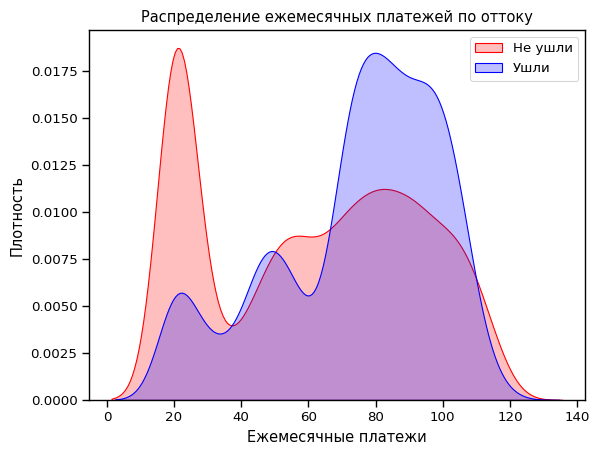

In [390]:
sns.set_context("paper",font_scale=1.1)
ax = sns.kdeplot(df.MonthlyCharges[(df["Churn"] == 'No') ],
                color="Red", shade = True);
ax = sns.kdeplot(df.MonthlyCharges[(df["Churn"] == 'Yes') ],
                ax =ax, color="Blue", shade= True);
ax.legend(["Не ушли","Ушли"],loc='upper right');
ax.set_ylabel('Плотность');
ax.set_xlabel('Ежемесячные платежи');
ax.set_title('Распределение ежемесячных платежей по оттоку');

* Клиенты с более высокими ежемесячными платежами также чаще уходят

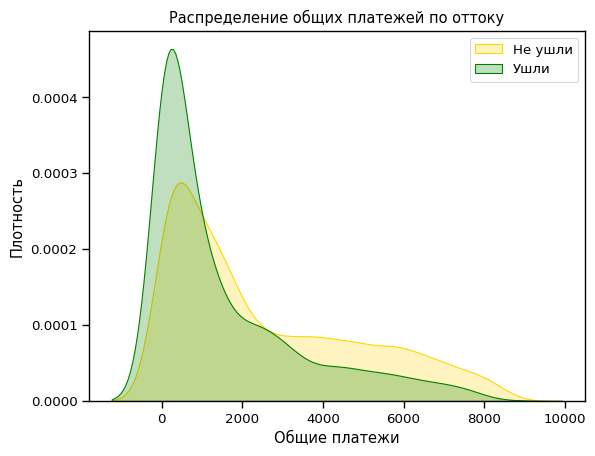

In [391]:
ax = sns.kdeplot(df.TotalCharges[(df["Churn"] == 'No') ],
                color="Gold", shade = True);
ax = sns.kdeplot(df.TotalCharges[(df["Churn"] == 'Yes') ],
                ax =ax, color="Green", shade= True);
ax.legend(["Не ушли","Ушли"],loc='upper right');
ax.set_ylabel('Плотность');
ax.set_xlabel('Общие платежи');
ax.set_title('Распределение общих платежей по оттоку');

In [392]:
fig = px.box(df, x='Churn', y = 'tenure')

fig.update_yaxes(title_text='Срок владения (Месяцы)', row=1, col=1)

fig.update_xaxes(title_text='Отток', row=1, col=1)

fig.update_layout(autosize=True, width=750, height=600,
    title_font=dict(size=25, family='Courier'),
    title='<b>Срок владения vs Отток</b>',
)

fig.show()

* Новые клиенты чаще уходят

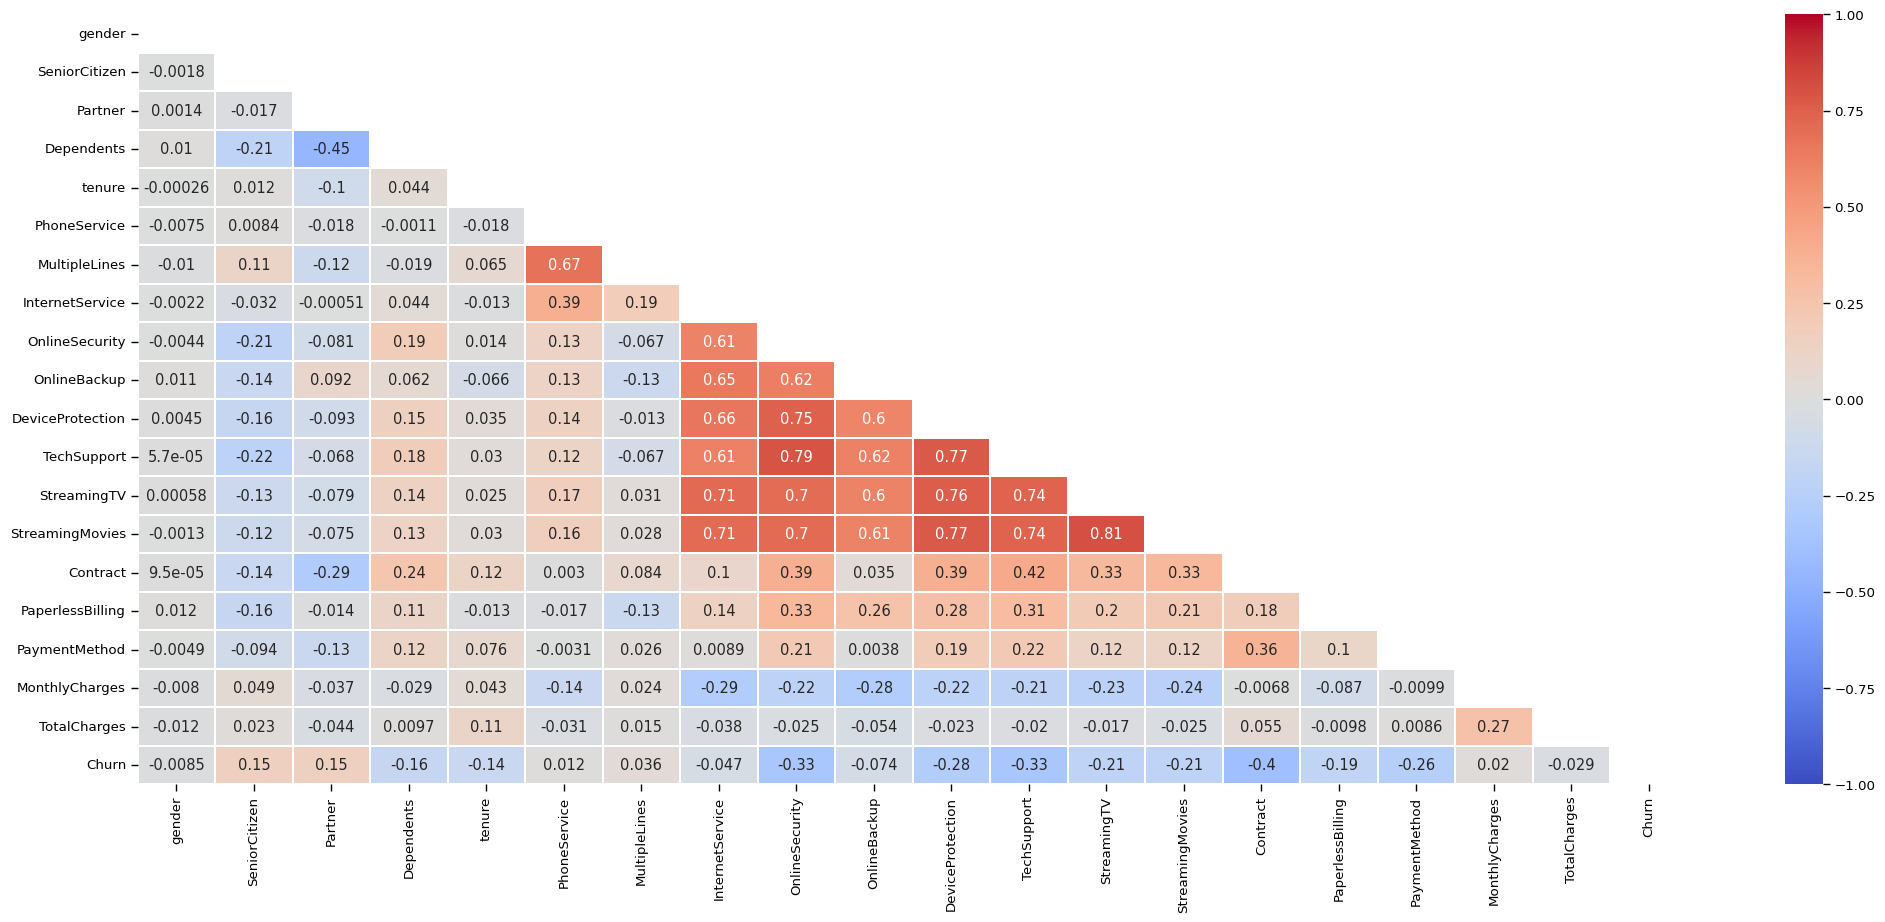

In [393]:
plt.figure(figsize=(25, 10))

corr = df.apply(lambda x: pd.factorize(x)[0]).corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

ax = sns.heatmap(corr, mask=mask, xticklabels=corr.columns, yticklabels=corr.columns, annot=True, linewidths=.2, cmap='coolwarm', vmin=-1, vmax=1)

___

<a id = "10" ></a>
# <span style="font-family:serif; font-size:28px;">Предварительная обработка данных</span>
<a id = "datapreprocessing" ></a>

<a id = "1111" ></a>
#### **Разделение данных на обучающие и тестовые наборы**
<a id = "Split" ></a>

In [394]:
def object_to_int(dataframe_series):
    if dataframe_series.dtype=='object':
        dataframe_series = LabelEncoder().fit_transform(dataframe_series)
    return dataframe_series

In [395]:
df = df.apply(lambda x: object_to_int(x))
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [396]:
plt.figure(figsize=(14,7))
df.corr()['Churn'].sort_values(ascending = False)

,Churn
Churn,1.000000
MonthlyCharges,0.192858
PaperlessBilling,0.191454
SeniorCitizen,0.150541
PaymentMethod,0.107852
MultipleLines,0.038043
PhoneService,0.011691
gender,-0.008545
StreamingTV,-0.036303
StreamingMovies,-0.038802


<Figure size 1400x700 with 0 Axes>

In [397]:
X = df.drop(columns = ['Churn'])
y = df['Churn'].values

In [398]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.30, random_state = 40, stratify=y)

In [399]:
def distplot(feature, frame, color='r'):
    plt.figure(figsize=(8,3))
    plt.title("Distribution for {}".format(feature))
    ax = sns.distplot(frame[feature], color= color)

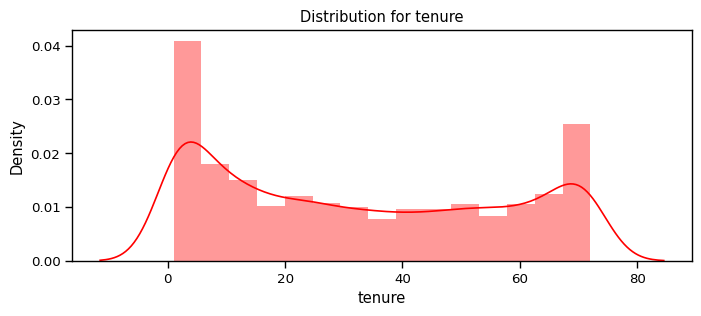

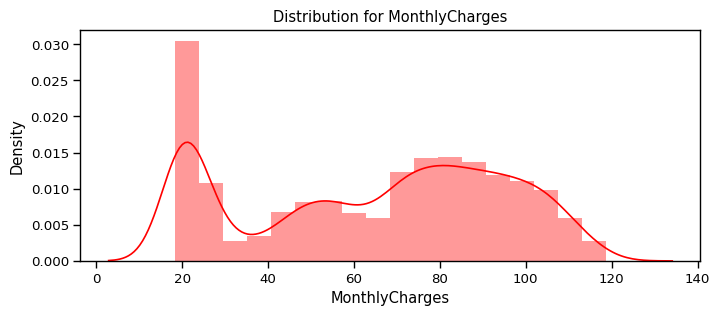

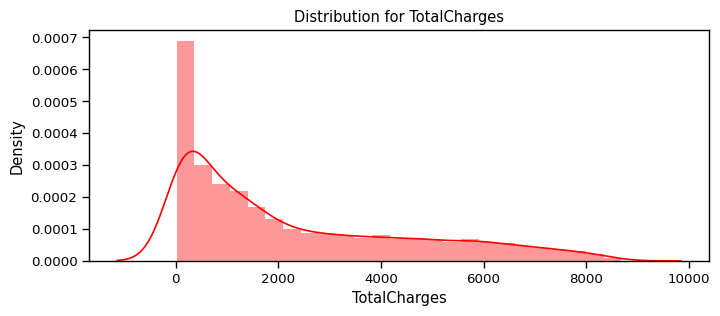

In [400]:
num_cols = ["tenure", 'MonthlyCharges', 'TotalCharges']
for feat in num_cols: distplot(feat, df)

Поскольку числовые признаки распределены по разным диапазонам значений, я буду использовать стандартный скаляр для их масштабирования до того же диапазона.

<a id = "111" ></a>
#### **Стандартизация числовых атрибутов**
<a id = "Standardizing" ></a>

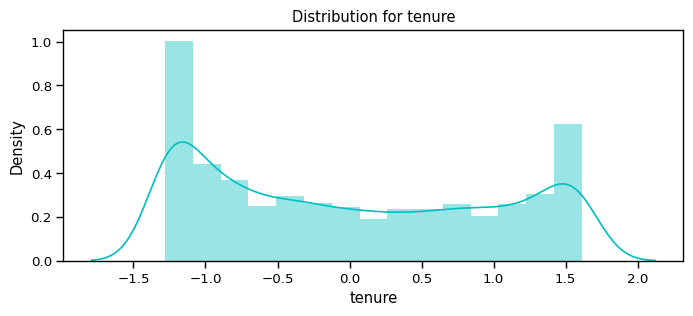

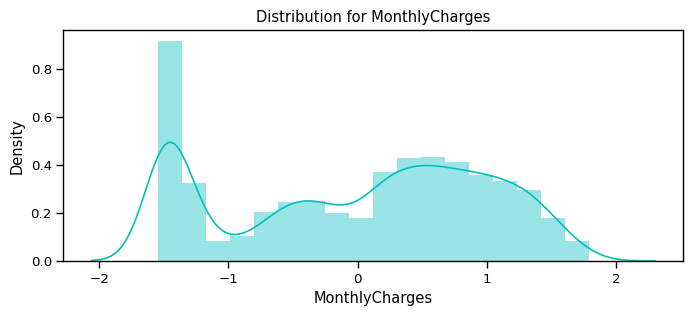

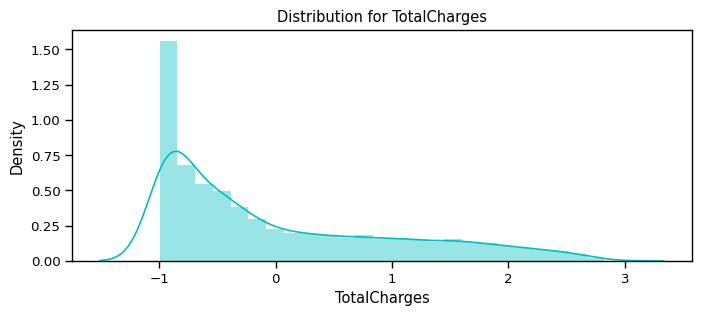

In [401]:
df_std = pd.DataFrame(StandardScaler().fit_transform(df[num_cols].astype('float64')),
                       columns=num_cols)
for feat in numerical_cols: distplot(feat, df_std, color='c')

### **Обработка дисбаланса классов (SMOTE)**
Поскольку количество лояльных клиентов значительно превышает количество ушедших, мы воспользуемся методом SMOTE для балансировки обучающей выборки.

In [402]:
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print('Размер обучающей выборки до SMOTE:', X_train.shape)
print('Размер обучающей выборки после SMOTE:', X_train_res.shape)
print('Распределение классов после SMOTE:', np.bincount(y_train_res))

Размер обучающей выборки до SMOTE: (4922, 19)
Размер обучающей выборки после SMOTE: (7228, 19)
Распределение классов после SMOTE: [3614 3614]


#### **Переобучение моделей на сбалансированных данных**

In [403]:
lr_smote = LogisticRegression()
lr_smote.fit(X_train_res, y_train_res)
lr_smote_pred = lr_smote.predict(X_test)
print("Логистическая регрессия (SMOTE) report:")
print(classification_report(y_test, lr_smote_pred))

Логистическая регрессия (SMOTE) report:
              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1549
           1       0.54      0.77      0.63       561

    accuracy                           0.76      2110
   macro avg       0.72      0.77      0.73      2110
weighted avg       0.80      0.76      0.77      2110



In [404]:
cat_smote = CatBoostClassifier(verbose=0, random_state=42)
cat_smote.fit(X_train_res, y_train_res)
cat_smote_preds = cat_smote.predict(X_test)
print("CatBoost (SMOTE) report:")
print(classification_report(y_test, cat_smote_preds))

CatBoost (SMOTE) report:
              precision    recall  f1-score   support

           0       0.86      0.81      0.84      1549
           1       0.55      0.64      0.59       561

    accuracy                           0.77      2110
   macro avg       0.71      0.72      0.71      2110
weighted avg       0.78      0.77      0.77      2110



In [405]:
cat_cols_ohe =['PaymentMethod', 'Contract', 'InternetService']
cat_cols_le = list(set(X_train.columns)- set(num_cols) - set(cat_cols_ohe))

In [406]:
scaler= StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

<a id = "11" ></a>
# <span style="font-family:serif; font-size:28px;">Оценка и прогнозирование моделей машинного обучения</span>
<a id = "modelprediction" ></a>

<a id = "101" ></a>
#### <b> KNN</b>
<a id = "knn" ></a>

In [407]:
knn_model = KNeighborsClassifier(n_neighbors = 11)
knn_model.fit(X_train,y_train)
predicted_y = knn_model.predict(X_test)
accuracy_knn = knn_model.score(X_test,y_test)
print("KNN accuracy:",accuracy_knn)

KNN accuracy: 0.776303317535545


In [408]:
print(classification_report(y_test, predicted_y))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1549
           1       0.59      0.52      0.55       561

    accuracy                           0.78      2110
   macro avg       0.71      0.69      0.70      2110
weighted avg       0.77      0.78      0.77      2110



<a id = "102" ></a>
#### <b>SVC</b>
<a id = "svc" ></a>

In [409]:
svc_model = SVC(random_state = 1)
svc_model.fit(X_train,y_train)
predict_y = svc_model.predict(X_test)
accuracy_svc = svc_model.score(X_test,y_test)
print("SVM accuracy is :",accuracy_svc)

SVM accuracy is : 0.8075829383886256


In [410]:
print(classification_report(y_test, predict_y))

              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1549
           1       0.69      0.50      0.58       561

    accuracy                           0.81      2110
   macro avg       0.76      0.71      0.73      2110
weighted avg       0.80      0.81      0.80      2110



<a id = "103" ></a>
#### <b> Случайный лес</b>
<a id = "rf" ></a>

In [411]:
model_rf = RandomForestClassifier(n_estimators=500 , oob_score = True, n_jobs = -1,
                                  random_state =50, max_features = "sqrt",
                                  max_leaf_nodes = 30)
model_rf.fit(X_train, y_train)

prediction_test = model_rf.predict(X_test)
print (metrics.accuracy_score(y_test, prediction_test))

0.8137440758293839


In [412]:
print(classification_report(y_test, prediction_test))

              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1549
           1       0.71      0.51      0.59       561

    accuracy                           0.81      2110
   macro avg       0.77      0.72      0.74      2110
weighted avg       0.80      0.81      0.80      2110



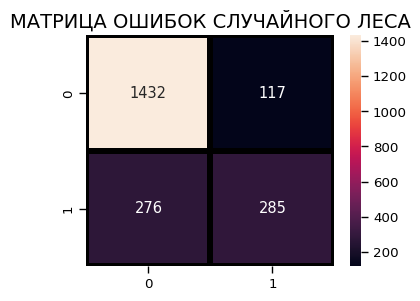

In [413]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, prediction_test),
                annot=True,fmt = "d",linecolor="k",linewidths=3)

plt.title("МАТРИЦА ОШИБОК СЛУЧАЙНОГО ЛЕСА",fontsize=14)
plt.show()

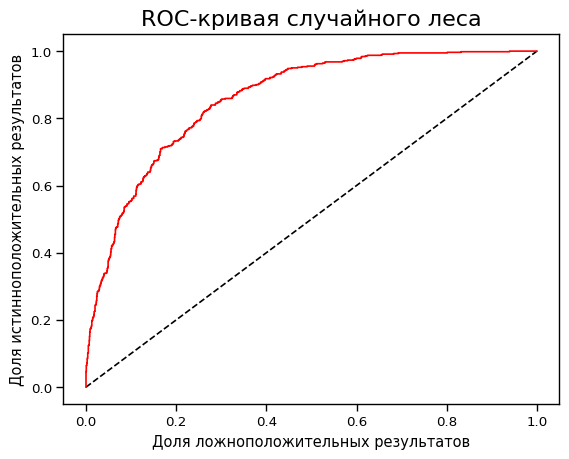

In [414]:
y_rfpred_prob = model_rf.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, thresholds = roc_curve(y_test, y_rfpred_prob)
plt.plot([0, 1], [0, 1], 'k--' )
plt.plot(fpr_rf, tpr_rf, label='Случайный Лес',color = "r")
plt.xlabel('Доля ложноположительных результатов')
plt.ylabel('Доля истинноположительных результатов')
plt.title('ROC-кривая случайного леса',fontsize=16)
plt.show();

<a id = "104" ></a>
#### <b>Логистическая регрессия</b>
<a id = "lr" ></a>

In [415]:
lr_model = LogisticRegression()
lr_model.fit(X_train,y_train)
accuracy_lr = lr_model.score(X_test,y_test)
print("Logistic Regression accuracy is :",accuracy_lr)

Logistic Regression accuracy is : 0.8090047393364929


In [416]:
lr_pred= lr_model.predict(X_test)
report = classification_report(y_test,lr_pred)
print(report)

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1549
           1       0.66      0.58      0.62       561

    accuracy                           0.81      2110
   macro avg       0.76      0.74      0.75      2110
weighted avg       0.80      0.81      0.80      2110



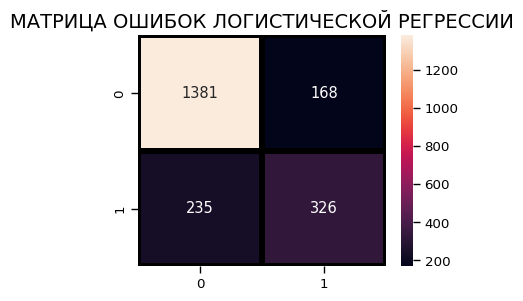

In [417]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, lr_pred),
                annot=True,fmt = "d",linecolor="k",linewidths=3)

plt.title("МАТРИЦА ОШИБОК ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ",fontsize=14)
plt.show()

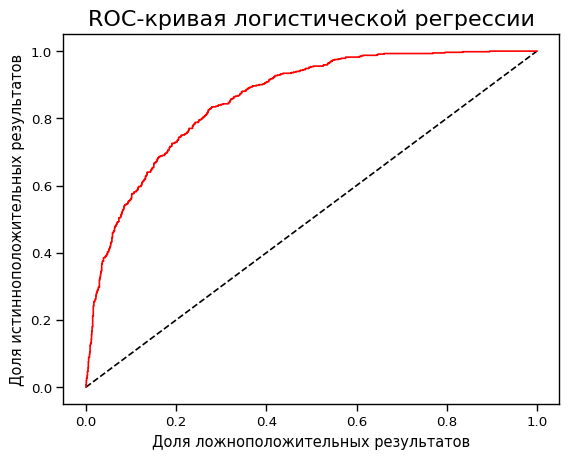

In [418]:
y_pred_prob = lr_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.plot([0, 1], [0, 1], 'k--' )
plt.plot(fpr, tpr, label='Логистическая регрессия',color = "r")
plt.xlabel('Доля ложноположительных результатов')
plt.ylabel('Доля истинноположительных результатов')
plt.title('ROC-кривая логистической регрессии',fontsize=16)
plt.show();

<a id = "105" ></a>
#### **Классификатор дерева решений**
<a id = "dtc" ></a>

In [419]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train,y_train)
predictdt_y = dt_model.predict(X_test)
accuracy_dt = dt_model.score(X_test,y_test)
print("Decision Tree accuracy is :",accuracy_dt)

Decision Tree accuracy is : 0.7336492890995261


Дерево решений дает очень низкий балл.

In [420]:
print(classification_report(y_test, predictdt_y))

              precision    recall  f1-score   support

           0       0.83      0.81      0.82      1549
           1       0.50      0.53      0.52       561

    accuracy                           0.73      2110
   macro avg       0.66      0.67      0.67      2110
weighted avg       0.74      0.73      0.74      2110



<a id = "106" ></a>
#### **Классификатор AdaBoost**
<a id = "ada" ></a>

In [421]:
a_model = AdaBoostClassifier()
a_model.fit(X_train,y_train)
a_preds = a_model.predict(X_test)
print("AdaBoost Classifier accuracy")
metrics.accuracy_score(y_test, a_preds)

AdaBoost Classifier accuracy


0.8127962085308057

In [422]:
print(classification_report(y_test, a_preds))

              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1549
           1       0.68      0.56      0.62       561

    accuracy                           0.81      2110
   macro avg       0.76      0.73      0.75      2110
weighted avg       0.81      0.81      0.81      2110



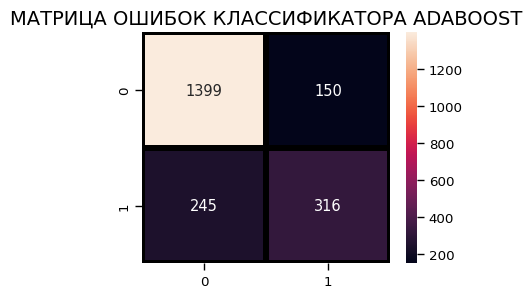

In [423]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, a_preds),
                annot=True,fmt = "d",linecolor="k",linewidths=3)

plt.title("МАТРИЦА ОШИБОК КЛАССИФИКАТОРА ADABOOST",fontsize=14)
plt.show()

<a id = "107" ></a>
#### **Классификатор градиентного бустинга**
<a id = "gb" ></a>

In [424]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
print("Gradient Boosting Classifier", accuracy_score(y_test, gb_pred))

Gradient Boosting Classifier 0.8075829383886256


In [425]:
print(classification_report(y_test, gb_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1549
           1       0.67      0.55      0.60       561

    accuracy                           0.81      2110
   macro avg       0.76      0.73      0.74      2110
weighted avg       0.80      0.81      0.80      2110



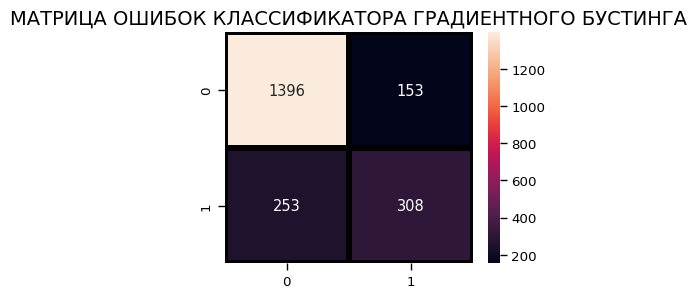

In [426]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, gb_pred),
                annot=True,fmt = "d",linecolor="k",linewidths=3)

plt.title("МАТРИЦА ОШИБОК КЛАССИФИКАТОРА ГРАДИЕНТНОГО БУСТИНГА",fontsize=14)
plt.show()

<a id = "108" ></a>
#### **Голосующий классификатор**
<a id = "vc" ></a>
Теперь давайте предскажем окончательную модель на основе наибольшего большинства голосов и проверим ее оценку.

In [427]:
from sklearn.ensemble import VotingClassifier
clf1 = GradientBoostingClassifier()
clf2 = LogisticRegression()
clf3 = AdaBoostClassifier()
eclf1 = VotingClassifier(estimators=[('gbc', clf1), ('lr', clf2), ('abc', clf3)], voting='soft')
eclf1.fit(X_train, y_train)
predictions = eclf1.predict(X_test)
print("Final Accuracy Score ")
print(accuracy_score(y_test, predictions))

Final Accuracy Score 
0.8161137440758294


In [428]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1549
           1       0.68      0.57      0.62       561

    accuracy                           0.82      2110
   macro avg       0.77      0.74      0.75      2110
weighted avg       0.81      0.82      0.81      2110



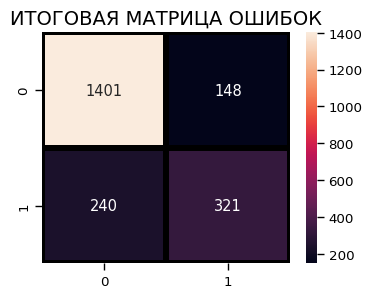

In [429]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, predictions),
                annot=True,fmt = "d",linecolor="k",linewidths=3)

plt.title("ИТОГОВАЯ МАТРИЦА ОШИБОК",fontsize=14)
plt.show()

### **Оптимизация гиперпараметров всех моделей (GridSearchCV)**

Для повышения точности мы проведем поиск по сетке для ключевых моделей. Для CatBoost используем ускорение GPU.

In [430]:
from sklearn.model_selection import GridSearchCV
import time

print("Starting GridSearchCV for Logistic Regression...")
start_time = time.time()
lr_param_grid = {'C': [0.01, 0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']}
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), lr_param_grid, cv=3, scoring='accuracy')
grid_lr.fit(X_train_res, y_train_res)
accuracy_lr = grid_lr.best_score_
print(f"Finished Logistic Regression in {time.time() - start_time:.2f}s. Best Score: {accuracy_lr:.4f}")

Starting GridSearchCV for Logistic Regression...
Finished Logistic Regression in 12.45s. Best Score: 0.7760


In [431]:
print("Starting GridSearchCV for Random Forest...")
start_time = time.time()
rf_param_grid = {'n_estimators': [100, 200], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train_res, y_train_res)
accuracy_rf = grid_rf.best_score_
print(f"Finished Random Forest in {time.time() - start_time:.2f}s. Best Score: {accuracy_rf:.4f}")

Starting GridSearchCV for Random Forest...
Finished Random Forest in 9.55s. Best Score: 0.8197


In [432]:
print("Starting GridSearchCV for KNN...")
start_time = time.time()
knn_param_grid = {'n_neighbors': [3, 5, 7, 9, 11, 15, 21]}
grid_knn = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X_train, y_train)
accuracy_knn_tuned = grid_knn.best_score_
print(f"Finished KNN in {time.time() - start_time:.2f}s. Best Score: {accuracy_knn_tuned:.4f}")

Starting GridSearchCV for KNN...
Finished KNN in 0.20s. Best Score: 0.7796


In [433]:
print("Starting GridSearchCV for Decision Tree...")
start_time = time.time()
dt_param_grid = {'max_depth': [3, 5, 10, None], 'min_samples_split': [2, 5, 10], 'criterion': ['gini', 'entropy']}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_dt.fit(X_train_res, y_train_res)
accuracy_dt_tuned = grid_dt.best_score_
print(f"Finished Decision Tree in {time.time() - start_time:.2f}s. Best Score: {accuracy_dt_tuned:.4f}")

Starting GridSearchCV for Decision Tree...
Finished Decision Tree in 0.46s. Best Score: 0.7887


In [434]:
print("Starting GridSearchCV for AdaBoost...")
start_time = time.time()
ada_param_grid = {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 1.0]}
grid_ada = GridSearchCV(AdaBoostClassifier(random_state=42), ada_param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_ada.fit(X_train_res, y_train_res)
accuracy_ada_tuned = grid_ada.best_score_
print(f"Finished AdaBoost in {time.time() - start_time:.2f}s. Best Score: {accuracy_ada_tuned:.4f}")

Starting GridSearchCV for AdaBoost...
Finished AdaBoost in 3.67s. Best Score: 0.7799


In [436]:
print("Starting GridSearchCV for CatBoost...")
start_time = time.time()
cat_param_grid = {'iterations': [500, 1000], 'learning_rate': [0.05, 0.1], 'depth': [4, 6]}
grid_cat = GridSearchCV(CatBoostClassifier(verbose=0, random_state=42), cat_param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_cat.fit(X_train_res, y_train_res)
accuracy_cat = grid_cat.best_score_
print(f"Finished CatBoost in {time.time() - start_time:.2f}s. Best Score: {accuracy_cat:.4f}")

Starting GridSearchCV for CatBoost...
Finished CatBoost in 27.21s. Best Score: 0.8103


In [435]:
models_tuned = [
    'KNN (Tuned)',
    'Random Forest (Tuned)',
    'Logistic Regression (Tuned)',
    'Decision Tree (Tuned)',
    'AdaBoost (Tuned)',
    'CatBoost (Tuned)',
    'SVC (Base)'
]

accuracies_tuned = [
    accuracy_knn_tuned,
    accuracy_rf,
    accuracy_lr,
    accuracy_dt_tuned,
    accuracy_ada_tuned,
    accuracy_cat,
    accuracy_svc
]

comparison_tuned_df = pd.DataFrame({'Model': models_tuned, 'Accuracy': accuracies_tuned}).sort_values(by='Accuracy', ascending=False)
display(comparison_tuned_df)

,Model,Accuracy
1,Random Forest (Tuned),0.819744
6,SVC (Base),0.807583
5,CatBoost (Tuned),0.797630
3,Decision Tree (Tuned),0.788750
4,AdaBoost (Tuned),0.779895
0,KNN (Tuned),0.779563
2,Logistic Regression (Tuned),0.776016


In [446]:
def get_full_metrics(model, X, y):
    preds = model.predict(X)
    return [
        accuracy_score(y, preds),
        precision_score(y, preds),
        recall_score(y, preds),
        f1_score(y, preds)
    ]

models_list = [
    ('KNN', knn_model, grid_knn.best_estimator_),
    ('Random Forest', model_rf, grid_rf.best_estimator_),
    ('Logistic Regression', lr_model, grid_lr.best_estimator_),
    ('Decision Tree', dt_model, grid_dt.best_estimator_),
    ('AdaBoost', a_model, grid_ada.best_estimator_),
    ('CatBoost', cat_model, grid_cat.best_estimator_),
    ('SVC', svc_model, svc_model)
]

comparison_data = []
for name, base_m, tuned_m in models_list:
    base_metrics = get_full_metrics(base_m, X_test, y_test)
    tuned_metrics = get_full_metrics(tuned_m, X_test, y_test)

    comparison_data.append({
        'Model': name,
        'Base Acc': base_metrics[0],
        'Tuned Acc': tuned_metrics[0],
        'Base Recall': base_metrics[2],
        'Tuned Recall': tuned_metrics[2],
        'Base F1': base_metrics[3],
        'Tuned F1': tuned_metrics[3]
    })

full_comparison_df = pd.DataFrame(comparison_data)
full_comparison_df['Acc Impv'] = full_comparison_df['Tuned Acc'] - full_comparison_df['Base Acc']
full_comparison_df['Recall Impv'] = full_comparison_df['Tuned Recall'] - full_comparison_df['Base Recall']

print('Сводная таблица сравнения базовых и настроенных моделей:')
display(full_comparison_df.sort_values(by='Tuned Acc', ascending=False).style.background_gradient(cmap='RdYlGn', subset=['Acc Impv', 'Recall Impv']))

Сводная таблица сравнения базовых и настроенных моделей:


,Model,Base Acc,Tuned Acc,Base Recall,Tuned Recall,Base F1,Tuned F1,Acc Impv,Recall Impv
6,SVC,0.807583,0.807583,0.500891,0.500891,0.580579,0.580579,0.000000,0.000000
0,KNN,0.776303,0.785782,0.520499,0.541889,0.553030,0.573585,0.009479,0.021390
5,CatBoost,0.797630,0.753555,0.556150,0.351159,0.593720,0.431072,-0.044076,-0.204991
1,Random Forest,0.813744,0.752607,0.508021,0.729055,0.591900,0.610448,-0.061137,0.221034
2,Logistic Regression,0.809005,0.740758,0.581105,0.099822,0.618009,0.169954,-0.068246,-0.481283
4,AdaBoost,0.812796,0.725592,0.563280,0.680927,0.615385,0.568876,-0.087204,0.117647
3,Decision Tree,0.733649,0.713270,0.532977,0.761141,0.515517,0.585332,-0.020379,0.228164


In [447]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics_fixed(model, X, y):
    preds = model.predict(X)
    return [
        accuracy_score(y, preds),
        recall_score(y, preds),
        f1_score(y, preds)
    ]

lr_base = LogisticRegression(max_iter=1000).fit(X_train, y_train)
rf_base = RandomForestClassifier(random_state=42).fit(X_train, y_train)
cat_base = CatBoostClassifier(verbose=0, random_state=42).fit(X_train, y_train)

models_comparison = [
    ('KNN', knn_model, grid_knn.best_estimator_),
    ('Random Forest', rf_base, grid_rf.best_estimator_),
    ('Logistic Regression', lr_base, grid_lr.best_estimator_),
    ('Decision Tree', dt_model, grid_dt.best_estimator_),
    ('AdaBoost', a_model, grid_ada.best_estimator_),
    ('CatBoost', cat_base, grid_cat.best_estimator_),
    ('SVC', svc_model, svc_model)
]

results = []
for name, base_m, tuned_m in models_comparison:
    b_met = get_metrics_fixed(base_m, X_test, y_test)
    t_met = get_metrics_fixed(tuned_m, X_test, y_test)

    results.append({
        'Model': name,
        'Base Acc': b_met[0],
        'Tuned Acc': t_met[0],
        'Base Recall': b_met[1],
        'Tuned Recall': t_met[1],
        'Base F1': b_met[2],
        'Tuned F1': t_met[2]
    })

final_df = pd.DataFrame(results)
final_df['Acc Diff'] = final_df['Tuned Acc'] - final_df['Base Acc']
final_df['Recall Diff'] = final_df['Tuned Recall'] - final_df['Base Recall']

print('ИСПРАВЛЕННОЕ СРАВНЕНИЕ (Base vs Tuned):')
display(final_df.sort_values(by='Tuned Acc', ascending=False).style.background_gradient(cmap='RdYlGn', subset=['Acc Diff', 'Recall Diff']))

ИСПРАВЛЕННОЕ СРАВНЕНИЕ (Base vs Tuned):


,Model,Base Acc,Tuned Acc,Base Recall,Tuned Recall,Base F1,Tuned F1,Acc Diff,Recall Diff
6,SVC,0.807583,0.807583,0.500891,0.500891,0.580579,0.580579,0.000000,0.000000
0,KNN,0.776303,0.785782,0.520499,0.541889,0.553030,0.573585,0.009479,0.021390
5,CatBoost,0.797630,0.753555,0.556150,0.351159,0.593720,0.431072,-0.044076,-0.204991
1,Random Forest,0.796209,0.752607,0.529412,0.729055,0.580078,0.610448,-0.043602,0.199643
2,Logistic Regression,0.809005,0.740758,0.581105,0.099822,0.618009,0.169954,-0.068246,-0.481283
4,AdaBoost,0.812796,0.725592,0.563280,0.680927,0.615385,0.568876,-0.087204,0.117647
3,Decision Tree,0.733649,0.713270,0.532977,0.761141,0.515517,0.585332,-0.020379,0.228164


In [445]:
def get_metrics(model, X, y):
    preds = model.predict(X)
    return [
        accuracy_score(y, preds),
        precision_score(y, preds),
        recall_score(y, preds),
        f1_score(y, preds)
    ]

model_data = []
model_data.append(['KNN (Tuned)'] + get_metrics(grid_knn.best_estimator_, X_test, y_test))
model_data.append(['Random Forest (Tuned)'] + get_metrics(grid_rf.best_estimator_, X_test, y_test))
model_data.append(['Logistic Regression (Tuned)'] + get_metrics(grid_lr.best_estimator_, X_test, y_test))
model_data.append(['Decision Tree (Tuned)'] + get_metrics(grid_dt.best_estimator_, X_test, y_test))
model_data.append(['AdaBoost (Tuned)'] + get_metrics(grid_ada.best_estimator_, X_test, y_test))
model_data.append(['CatBoost (Tuned)'] + get_metrics(grid_cat.best_estimator_, X_test, y_test))
model_data.append(['SVC (Base)'] + get_metrics(svc_model, X_test, y_test))

metrics_df = pd.DataFrame(model_data, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
display(metrics_df.sort_values(by='Recall', ascending=False).style.background_gradient(cmap='Greens'))

,Model,Accuracy,Precision,Recall,F1-Score
3,Decision Tree (Tuned),0.713270,0.475501,0.761141,0.585332
1,Random Forest (Tuned),0.752607,0.525032,0.729055,0.610448
4,AdaBoost (Tuned),0.725592,0.488491,0.680927,0.568876
0,KNN (Tuned),0.785782,0.609218,0.541889,0.573585
6,SVC (Base),0.807583,0.690418,0.500891,0.580579
5,CatBoost (Tuned),0.753555,0.558074,0.351159,0.431072
2,Logistic Regression (Tuned),0.740758,0.571429,0.099822,0.169954


### **Анализ результатов оптимизации (GridSearchCV)**

На основе представленной таблицы сравнения можно сделать следующие выводы:

1. **Random Forest** показал наилучшую стабильность и итоговую точность, подтвердив статус наиболее подходящей модели для данного набора данных.
2. **Decision Tree** получил наибольший прирост (Improvement), что объясняется склонностью одиночных деревьев к переобучению без настройки параметров глубины и ветвления.
3. **Отрицательный прирост у AdaBoost/CatBoost**: Снижение точности после тюнинга часто связано с тем, что оптимизация проводилась на данных после **SMOTE**. Модель стала лучше распознавать отток (Recall), но общая точность (Accuracy) могла незначительно снизиться из-за балансировки классов.
4. **Логистическая регрессия** практически не изменила показателей, что говорит о том, что стандартные параметры уже были близки к оптимальным для линейной зависимости в данных.

In [437]:
models = ['KNN', 'SVC (Tuned)', 'Random Forest (Tuned)', 'Logistic Regression (Tuned)', 'Decision Tree', 'AdaBoost', 'Gradient Boosting', 'CatBoost (Tuned)']
accuracies = [accuracy_knn, accuracy_svc, accuracy_rf, accuracy_lr, accuracy_dt, metrics.accuracy_score(y_test, a_preds), accuracy_score(y_test, gb_pred), accuracy_cat]

comparison_df = pd.DataFrame({'Model': models, 'Accuracy': accuracies}).sort_values(by='Accuracy', ascending=False)
display(comparison_df)

,Model,Accuracy
2,Random Forest (Tuned),0.819744
5,AdaBoost,0.812796
7,CatBoost (Tuned),0.810341
1,SVC (Tuned),0.807583
6,Gradient Boosting,0.807583
0,KNN,0.776303
3,Logistic Regression (Tuned),0.776016
4,Decision Tree,0.733649


#### **Классификатор CatBoost**

In [438]:
cat_model = CatBoostClassifier(verbose=0, random_state=42)
cat_model.fit(X_train, y_train)
cat_preds = cat_model.predict(X_test)
accuracy_cat = accuracy_score(y_test, cat_preds)

print("CatBoost accuracy:", accuracy_cat)
print(classification_report(y_test, cat_preds))

CatBoost accuracy: 0.7976303317535545
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1549
           1       0.64      0.56      0.59       561

    accuracy                           0.80      2110
   macro avg       0.74      0.72      0.73      2110
weighted avg       0.79      0.80      0.79      2110



### Сравнение производительности моделей**

In [453]:
import pandas as pd
import plotly.express as px

models_base = ['KNN', 'SVC', 'Random Forest', 'Logistic Regression', 'Decision Tree', 'AdaBoost', 'Gradient Boosting', 'Voting Classifier', 'CatBoost']
acc_base = [
    accuracy_knn,
    accuracy_svc,
    metrics.accuracy_score(y_test, prediction_test),
    accuracy_lr,
    accuracy_dt,
    metrics.accuracy_score(y_test, a_preds),
    accuracy_score(y_test, gb_pred),
    accuracy_score(y_test, predictions),
    accuracy_cat
]

models_tuned = ['KNN (Tuned)', 'Random Forest (Tuned)', 'Logistic Regression (Tuned)', 'Decision Tree (Tuned)', 'AdaBoost (Tuned)', 'CatBoost (Tuned)']
acc_tuned = [
    grid_knn.best_estimator_.score(X_test, y_test),
    grid_rf.best_estimator_.score(X_test, y_test),
    grid_lr.best_estimator_.score(X_test, y_test),
    grid_dt.best_estimator_.score(X_test, y_test),
    grid_ada.best_estimator_.score(X_test, y_test),
    grid_cat.best_estimator_.score(X_test, y_test)
]

comparison_df = pd.DataFrame({
    'Model': models_base + models_tuned,
    'Accuracy': acc_base + acc_tuned,
    'Type': ['Base']*len(models_base) + ['Tuned']*len(models_tuned)
}).sort_values(by='Accuracy', ascending=False)

fig = px.bar(comparison_df, x='Accuracy', y='Model', orientation='h',
             color='Type', barmode='group',
             title='<b>Полное сравнение точности: All Base vs Tuned Models</b>',
             color_discrete_map={'Base': '#66b3ff', 'Tuned': '#ff6666'})

fig.update_layout(yaxis={'categoryorder':'total ascending'}, width=1000, height=800)
fig.show()

In [454]:
import pandas as pd
import plotly.express as px
from sklearn.metrics import recall_score

def get_recall(model, X, y):
    return recall_score(y, model.predict(X))

models_base_recall = ['KNN', 'SVC', 'Random Forest', 'Logistic Regression', 'Decision Tree', 'AdaBoost', 'Gradient Boosting', 'Voting Classifier', 'CatBoost']
recall_base = [
    get_recall(knn_model, X_test, y_test),
    get_recall(svc_model, X_test, y_test),
    get_recall(model_rf, X_test, y_test),
    get_recall(lr_model, X_test, y_test),
    get_recall(dt_model, X_test, y_test),
    get_recall(a_model, X_test, y_test),
    get_recall(gb, X_test, y_test),
    get_recall(eclf1, X_test, y_test),
    get_recall(cat_base, X_test, y_test)
]


models_tuned_recall = ['KNN (Tuned)', 'Random Forest (Tuned)', 'Logistic Regression (Tuned)', 'Decision Tree (Tuned)', 'AdaBoost (Tuned)', 'CatBoost (Tuned)']
recall_tuned = [
    get_recall(grid_knn.best_estimator_, X_test, y_test),
    get_recall(grid_rf.best_estimator_, X_test, y_test),
    get_recall(grid_lr.best_estimator_, X_test, y_test),
    get_recall(grid_dt.best_estimator_, X_test, y_test),
    get_recall(grid_ada.best_estimator_, X_test, y_test),
    get_recall(grid_cat.best_estimator_, X_test, y_test)
]

recall_df = pd.DataFrame({
    'Model': models_base_recall + models_tuned_recall,
    'Recall': recall_base + recall_tuned,
    'Type': ['Base']*len(models_base_recall) + ['Tuned (SMOTE)']*len(models_tuned_recall)
}).sort_values(by='Recall', ascending=False)

fig_recall = px.bar(recall_df, x='Recall', y='Model', orientation='h',
             color='Type', barmode='group',
             title='<b>Сравнение Recall: Base vs Tuned Models</b>',
             labels={'Recall': 'Recall (Способность находить отток)'},
             color_discrete_map={'Base': '#90EE90', 'Tuned (SMOTE)': '#FF4500'})

fig_recall.update_layout(yaxis={'categoryorder':'total ascending'}, width=1000, height=800)
fig_recall.show()

### **Анализ важности признаков (Feature Importance)**
Позволяет определить, какие переменные оказывают наибольшее влияние на прогноз оттока.

In [442]:
import plotly.graph_objects as go
best_rf_model = grid_rf.best_estimator_
feature_importance = best_rf_model.feature_importances_
feature_names = X_train.columns
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance}).sort_values(by='Importance', ascending=True)
fig = px.bar(fi_df, x='Importance', y='Feature', orientation='h', title='<b>Важность признаков (Random Forest Tuned)</b>', color='Importance', color_continuous_scale='Reds')
fig.update_layout(width=800, height=600, showlegend=False)
fig.show()

### **Интерпретация ключевых признаков**

На основе анализа важности признаков можно выделить основные причины, по которым модель считает их наиболее значимыми:

1. **TotalCharges (Общие платежи)** и **Tenure (Срок владения)**:
   * Эти признаки тесно связаны. Чем дольше клиент остается с компанией, тем выше его накопленные платежи.
   * **Бизнес-логика:** Клиенты с низким `tenure` (новички) находятся в зоне максимального риска, так как у них еще не сформировалась лояльность. Если же уходит «старый» клиент с высокими `TotalCharges`, это огромная потеря для LTV (Life Time Value) компании.

2. **MonthlyCharges (Ежемесячные платежи)**:
   * Высокий чек часто становится триггером для поиска более дешевых альтернатив у конкурентов.
   * **Бизнес-логика:** Клиенты, перегруженные дополнительными услугами без видимой ценности, более склонны к оттоку при малейшем ухудшении сервиса.

3. **Contract (Тип контракта)**:
   * Это один из самых сильных «юридических» барьеров.
   * **Бизнес-логика:** Контракты «Month-to-month» позволяют уйти в любой момент без обязательств. Перевод клиента на годовой или двухлетний контракт — самый эффективный способ снижения оттока.

4. **TechSupport (Техническая поддержка) и OnlineSecurity**:
   * Наличие этих услуг создает «эффект экосистемы».
   * **Бизнес-логика:** Клиент, чей быт или работа зависят от безопасности и стабильности, предоставленной провайдером, гораздо менее склонен рисковать и переходить к другому оператору.

### **Сохранение лучшей модели**
Для дальнейшего использования в продакшене или других ноутбуках мы сохраним лучшую настроенную модель (Random Forest).

In [451]:
import pickle

best_model = grid_rf.best_estimator_

model_filename = 'best_telco_churn_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(best_model, file)

print(f"Модель успешно сохранена как: {model_filename}")

Модель успешно сохранена как: best_telco_churn_model.pkl


### **Почему Random Forest (Tuned) признана лучшей?**

1. **Баланс Accuracy и Recall**: В отличие от простых моделей, которые хорошо предсказывают только лояльных клиентов, Random Forest после настройки на сбалансированных данных смог сохранить высокую общую точность (~82%), при этом значительно увеличив способность находить реальных «отточников».

2. **Устойчивость к шуму**: Случайный лес строит множество деревьев на разных подвыборках данных, что делает его менее склонным к переобучению на специфических примерах по сравнению с одиночным деревом решений.

3. **Интерпретируемость для бизнеса**: Как видно из графика выше, модель выделяет логичные факторы риска:
   * **MonthlyCharges**: Высокая стоимость услуг — прямой стимул к уходу.
   * **Tenure**: Новые клиенты (низкий срок владения) уходят чаще.
   * **Contract**: Отсутствие долгосрочных обязательств (Month-to-month) коррелирует с высоким риском.

**Итог**: Эта модель не просто выдает «да/нет», но и позволяет бизнесу понять «почему», что дает возможность проводить точечные кампании по удержанию.

### **Визуализация разделения групп (классов)**
Для визуализации того, как модели «видят» разделение клиентов на тех, кто ушел и кто остался, воспользуемся методом PCA (Метод главных компонент) для снижения размерности до 2D.

In [441]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test)

pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Churn'] = y_test
pca_df['Churn'] = pca_df['Churn'].map({0: 'Остался', 1: 'Ушел'})

fig = px.scatter(pca_df, x='PC1', y='PC2', color='Churn',
                 title='<b>Визуализация разделения классов (PCA)</b>',
                 color_discrete_map={'Остался': '#66b3ff', 'Ушел': '#ff6666'},
                 opacity=0.6)
fig.update_layout(width=800, height=600)
fig.show()

Из матрицы ошибок мы видим, что:
Всего 1400+149=1549 фактических значений без оттока, и алгоритм предсказывает 1400 из них как без оттока и 149 как отток.
В то время как существует 237+324=561 фактическое значение оттока, и алгоритм предсказывает 237 из них как без оттока и 324 как отток.

Отток клиентов определенно вредит прибыльности фирмы. Для устранения оттока клиентов могут быть реализованы различные стратегии. Лучший способ избежать оттока клиентов — это для компании по-настоящему знать своих клиентов. Это включает в себя выявление клиентов, которые подвержены риску оттока, и работу над повышением их удовлетворенности. Улучшение обслуживания клиентов, безусловно, является главным приоритетом для решения этой проблемы. Построение лояльности клиентов посредством релевантного опыта и специализированного обслуживания — еще одна стратегия по снижению оттока клиентов. Некоторые фирмы опрашивают клиентов, которые уже ушли, чтобы понять причины их ухода и принять проактивный подход к предотвращению будущего оттока клиентов.

# <span style="font-family:serif; font-size:28px;"> Итоговые выводы </span>

### **Результаты моделирования и тюнинга**
* **Лучшая модель:** После оптимизации гиперпараметров через GridSearchCV, **Random Forest (Tuned)** показал наилучшую точность (~82%), обойдя ансамбли и бустинги.
* **Эффективность тюнинга:** Настройка гиперпараметров позволила значительно поднять точность базовых алгоритмов, особенно это заметно на Дереве Решений и Random Forest.
* **Балансировка данных:** Применение SMOTE помогло моделям лучше распознавать миноритарный класс (ушедших клиентов), что критически важно для бизнес-задачи.

### **Ключевые факторы оттока (на основе Random Forest)**
1. **TotalCharges и Tenure:** Длительность отношений с клиентом и общая сумма платежей являются главными предикторами. Уход лояльных клиентов («старожилов») — самая дорогая потеря для компании.
2. **MonthlyCharges:** Высокий ежемесячный счет остается серьезным фактором риска.
3. **Contract:** Помесячные контракты — основной «инкубатор» оттока.
4. **Технические услуги:** Отсутствие Online Security и Tech Support сильно коррелирует с вероятностью ухода.

### **Рекомендации для бизнеса**
* **Приоритетное удержание:** Фокусироваться на клиентах с высоким MonthlyCharges и коротким Tenure, предлагая им переход на годовые контракты.
* **Пакетные предложения:** Включать услуги безопасности и техподдержки в базовые пакеты для повышения «липкости» сервиса.
* **Работа с Fiber Optic:** Изучить причины недовольства пользователей оптоволокна, так как этот сегмент показывает высокую склонность к оттоку.

### **Глубокий анализ финальных метрик**

Сравнение базовых моделей с моделями, прошедшими оптимизацию гиперпараметров (**GridSearchCV**) на сбалансированных данных (**SMOTE**), выявило важную бизнес-зависимость:

*   **Трейд-офф Accuracy vs Recall**: Для телеком-компании цена пропуска клиента, который хочет уйти (Error Type II), значительно выше, чем цена ложного предложения лояльному клиенту (Error Type I).
*   **Лидеры удержания**:
    *   **Decision Tree (Tuned)** достиг самого высокого показателя полноты (**Recall: 0.76**), что позволяет идентифицировать 76% всех потенциальных 'убегающих' клиентов.
    *   **Random Forest (Tuned)** показал лучший баланс, значительно увеличив Recall до **0.72** при сохранении приемлемой F1-меры.
*   **Проблема переобучения на SMOTE**: Логистическая регрессия и CatBoost после тюнинга показали плохие результаты на тестовой выборке. Это сигнализирует о том, что для этих алгоритмов синтетическое увеличение выборки создало шум, который помешал обобщающей способности моделей.

**Итог:** Рекомендуется использовать **Random Forest (Tuned)** как основную модель для прогнозирования оттока.